---
title: "Penguins"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Palmer Penguins
- **description:** Body-size measurements for 344 penguins of three species observed on three islands of the Palmer Archipelago, Antarctica.
- **provenance:** Gorman, K. B., Williams, T. D. & Fraser, W. R. (2014), *PLoS ONE* 9(3); data from the Palmer Station Long-Term Ecological Research (LTER) program, packaged as `palmerpenguins` by Horst, Hill & Gorman.
- **format:** long / tidy — 344 rows x 7 columns.

**Data dictionary**

- `species` — *(identifier)* `Adelie`, `Chinstrap`, or `Gentoo`.
- `island` — *(identifier)* `Torgersen`, `Biscoe`, or `Dream`.
- `bill_length_mm` — *(measurement)* bill length in millimetres.
- `bill_depth_mm` — *(measurement)* bill depth in millimetres.
- `flipper_length_mm` — *(measurement)* flipper length in millimetres.
- `body_mass_g` — *(measurement)* body mass in grams.
- `sex` — *(identifier)* `Male` or `Female`.

**Structure**

- **Rows:** 344 — one row per penguin (a few rows have missing measurements).
- **Columns:** 7.
- **Identifiers:** `species`, `island`, `sex`.
- **Measurements:** the four body dimensions.

**Use cases**

- classification and clustering (an iris alternative)
- scatter plots by species and island
- grouped aggregation across nominal identifiers


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Long form (tidy)

In [67]:
penguins = sns.load_dataset('penguins').dropna()
penguins.info()
penguins

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [71]:
penguins_nominals = ['species','sex', 'island']
penguins_measures = list(set(penguins.columns) - set(penguins_nominals))
penguins_measures

['bill_depth_mm', 'bill_length_mm', 'body_mass_g', 'flipper_length_mm']

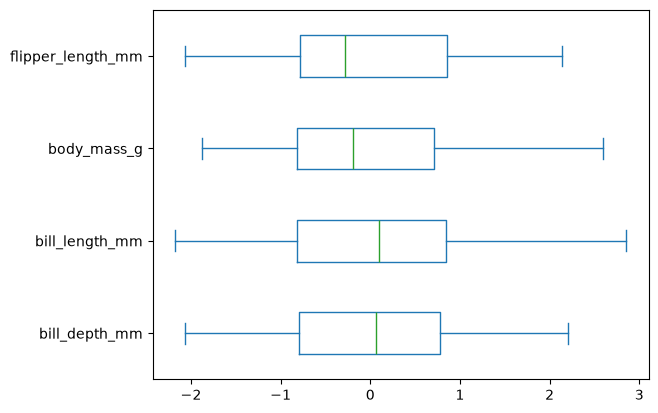

In [80]:
((penguins[penguins_measures] - penguins[penguins_measures].mean()) / penguins[penguins_measures].std()).plot.box(vert=False)
plt.show()

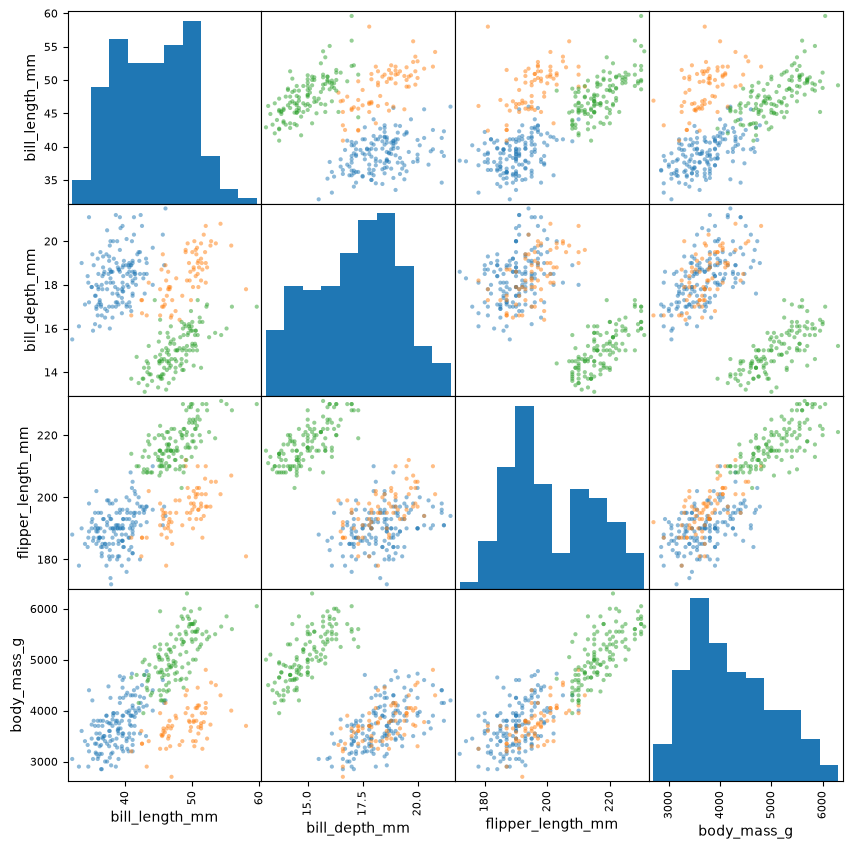

In [79]:
cmap = plt.get_cmap('tab10')
color_map = {species:cmap(i) for i, species in enumerate(penguins.species.unique())}
pd.plotting.scatter_matrix(penguins, c=penguins.species.map(color_map), figsize=(10,10))
plt.show()

## Long form value counts of joint identifiers

In [99]:
penguins_counts = penguins.value_counts(penguins_nominals).to_frame('n')
penguins_counts['p'] = penguins_counts['n'] / penguins_counts['n'].sum()
penguins_counts

n         p
species   sex    island                 
Gentoo    Male   Biscoe     61  0.183183
          Female Biscoe     58  0.174174
Chinstrap Female Dream      34  0.102102
          Male   Dream      34  0.102102
Adelie    Male   Dream      28  0.084084
          Female Dream      27  0.081081
                 Torgersen  24  0.072072
          Male   Torgersen  23  0.069069
          Female Biscoe     22  0.066066
          Male   Biscoe     22  0.066066

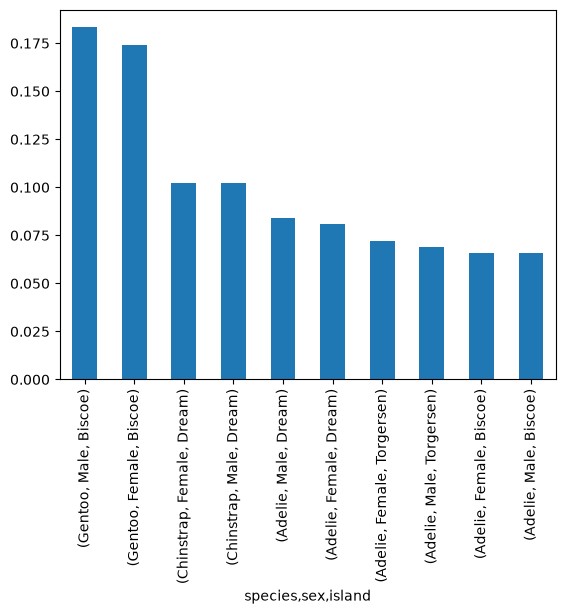

In [110]:
penguins_counts['p'].plot.bar()
plt.show()

## Value counts of single nominals

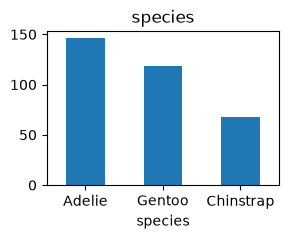

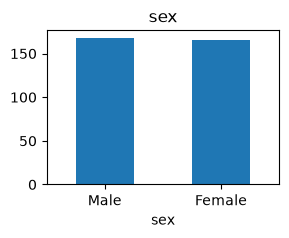

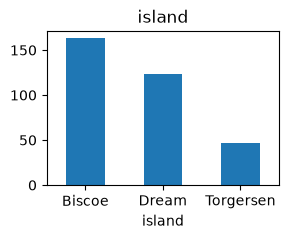

In [117]:
for col in penguins_nominals:
    penguins.value_counts(col).plot.bar(title=col, rot=0, figsize=(3,2))
    plt.show()

## Wide form of counts 2 by 1

In [137]:
penguins_counts['n'].unstack(fill_value=0)

island            Torgersen  Biscoe  Dream
species   sex                             
Adelie    Male           23      22     28
          Female         24      22     27
Chinstrap Male            0       0     34
          Female          0       0     34
Gentoo    Male            0      61      0
          Female          0      58      0

In [92]:
penguins.value_counts(penguins_nominals).unstack(fill_value=0)

island            Torgersen  Biscoe  Dream
species   sex                             
Adelie    Male           23      22     28
          Female         24      22     27
Chinstrap Male            0       0     34
          Female          0       0     34
Gentoo    Male            0      61      0
          Female          0      58      0

## Wide form of counts 1 x 1

In [140]:
penguins_counts['n'].unstack(fill_value=0).groupby('species').sum()

island,Torgersen,Biscoe,Dream
species,,,
Adelie,47,44,55
Chinstrap,0,0,68
Gentoo,0,119,0


In [122]:
penguins.value_counts(['species','island']).unstack(fill_value=0)

island,Torgersen,Biscoe,Dream
species,,,
Adelie,47,44,55
Chinstrap,0,0,68
Gentoo,0,119,0


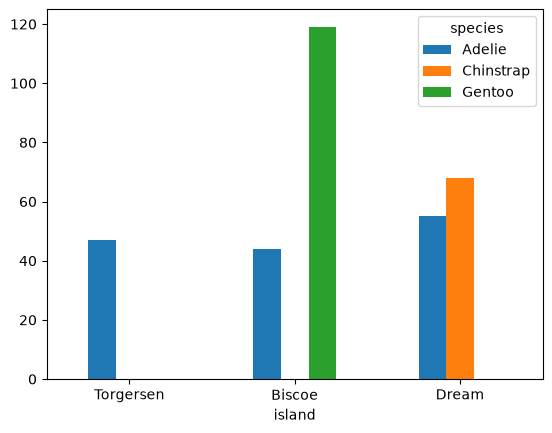

In [125]:
penguins.value_counts(['species','island']).unstack(fill_value=0).T.plot.bar(rot=0)
plt.show()

## Long form aggregated by three nominal identifiers

In [124]:
penguins1 = penguins1.groupby(penguins_nominals).mean()
penguins1

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex    island                                                        
Adelie    Female Biscoe          37.359091      17.704545         187.181818   
                 Dream           36.911111      17.618519         187.851852   
                 Torgersen       37.554167      17.550000         188.291667   
          Male   Biscoe          40.590909      19.036364         190.409091   
                 Dream           40.071429      18.839286         191.928571   
                 Torgersen       40.586957      19.391304         194.913043   
Chinstrap Female Dream           46.573529      17.588235         191.735294   
          Male   Dream           51.094118      19.252941         199.911765   
Gentoo    Female Biscoe          45.563793      14.237931         212.706897   
          Male   Biscoe          49.473770      15.718033         221.540984   

                            body_mass_g  
species   sex    island                  
Adelie    Female Biscoe     3369.318182  
                 Dream      3344.444444  
                 Torgersen  3395.833333  
          Male   Biscoe     4050.000000  
                 Dream      4045.535714  
                 Torgersen  4034.782609  
Chinstrap Female Dream      3527.205882  
          Male   Dream      3938.970588  
Gentoo    Female Biscoe     4679.741379  
          Male   Biscoe     5484.836066

## Wide form of measure 2 by 1

In [88]:
penguins1.bill_length_mm.unstack(fill_value=0)

island               Biscoe      Dream  Torgersen
species   sex                                    
Adelie    Female  37.359091  36.911111  37.554167
          Male    40.590909  40.071429  40.586957
Chinstrap Female   0.000000  46.573529   0.000000
          Male     0.000000  51.094118   0.000000
Gentoo    Female  45.563793   0.000000   0.000000
          Male    49.473770   0.000000   0.000000

## Long form aggregated by two nominal identifiers

In [5]:
penguins2a = penguins1.groupby(['species','island']).mean()
penguins2a

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   island                                                        
Adelie    Biscoe          38.975000      18.370455         188.795455   
          Dream           38.501786      18.251786         189.732143   
          Torgersen       38.950980      18.429412         191.196078   
Chinstrap Dream           48.833824      18.420588         195.823529   
Gentoo    Biscoe          47.504878      14.982114         217.186992   

                     body_mass_g  
species   island                  
Adelie    Biscoe     3709.659091  
          Dream      3688.392857  
          Torgersen  3706.372549  
Chinstrap Dream      3733.088235  
Gentoo    Biscoe     5076.016260

In [6]:
penguins2b = penguins1.groupby(['species','sex']).mean()
penguins2b

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    Female       37.257534      17.621918         187.794521   
          Male         40.390411      19.072603         192.410959   
Chinstrap Female       46.573529      17.588235         191.735294   
          Male         51.094118      19.252941         199.911765   
Gentoo    Female       45.563793      14.237931         212.706897   
          Male         49.473770      15.718033         221.540984   

                  body_mass_g  
species   sex                  
Adelie    Female  3368.835616  
          Male    4043.493151  
Chinstrap Female  3527.205882  
          Male    3938.970588  
Gentoo    Female  4679.741379  
          Male    5484.836066

In [7]:
penguins2c = penguins1.groupby(['island','sex']).mean()
penguins2c

bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    sex                                                        
Biscoe    Female       43.307500      15.191250         205.687500   
          Male         47.119277      16.597590         213.289157   
Dream     Female       42.296721      17.601639         190.016393   
          Male         46.116129      19.066129         196.306452   
Torgersen Female       37.554167      17.550000         188.291667   
          Male         40.586957      19.391304         194.913043   

                  body_mass_g  
island    sex                  
Biscoe    Female  4319.375000  
          Male    5104.518072  
Dream     Female  3446.311475  
          Male    3987.096774  
Torgersen Female  3395.833333  
          Male    4034.782609

## Wide form of measure 1 by 1

In [142]:
penguins4a = penguins2a.bill_length_mm.unstack(fill_value=0)
penguins4a

island,Biscoe,Dream,Torgersen
species,,,
Adelie,38.975000,38.501786,38.95098
Chinstrap,0.000000,48.833824,0.00000
Gentoo,47.504878,0.000000,0.00000


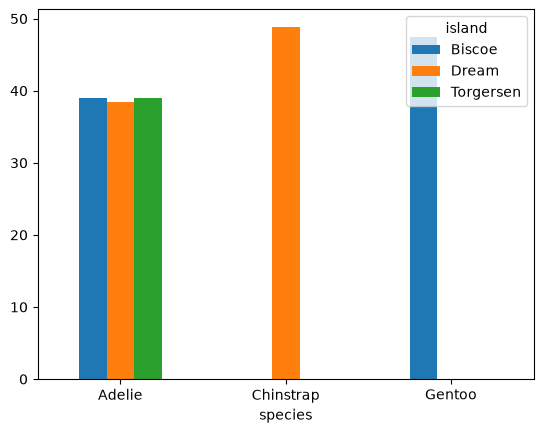

In [143]:
penguins4a.plot.bar(rot=0)
plt.show()

In [144]:
penguins4b = penguins2c.body_mass_g.unstack()
penguins4b

sex,Female,Male
island,,
Biscoe,4319.375000,5104.518072
Dream,3446.311475,3987.096774
Torgersen,3395.833333,4034.782609


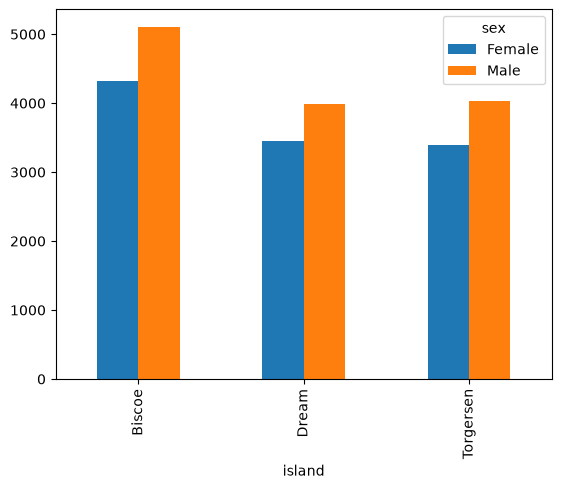

In [145]:
penguins4b.plot.bar()
plt.show()

## Long form aggregated by one nominal

In [146]:
penguins3a = penguins1.groupby('island').mean()
penguins3a

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
island,,,,
Biscoe,43.246891,16.674218,202.959697,4395.973907
Dream,43.662547,18.324745,192.856871,3714.039157
Torgersen,39.070562,18.470652,191.602355,3715.307971


In [147]:
penguins3a.style.format(precision=2).background_gradient()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
island,,,,
Biscoe,43.25,16.67,202.96,4395.97
Dream,43.66,18.32,192.86,3714.04
Torgersen,39.07,18.47,191.60,3715.31


In [148]:
penguins3b = penguins1.groupby('sex').mean()
penguins3b

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
sex,,,,
Female,40.792338,16.939846,193.553505,3663.308644
Male,44.363436,18.447586,199.740691,4310.824995


In [149]:
penguins3b.style.format(precision=2).background_gradient()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
sex,,,,
Female,40.79,16.94,193.55,3663.31
Male,44.36,18.45,199.74,4310.82


In [150]:
penguins3c = penguins1.groupby('species').mean()
penguins3c

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.845610,18.356670,190.096007,3706.652380
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.518782,14.977982,217.123940,5082.288722


In [132]:
penguins3c.style.format(precision=2).background_gradient()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.85,18.36,190.10,3706.65
Chinstrap,48.83,18.42,195.82,3733.09
Gentoo,47.52,14.98,217.12,5082.29
